In [11]:
"""
synthesize_and_test_peaks.py

Requirements:
    pip install numpy pandas matplotlib scipy

What it does:
    - synthesize a timeseries with N peaks (Gaussian rise + exponential decay tail)
    - add Gaussian noise
    - save CSV and plot
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import os

In [18]:
def synthesize_peaks_list(n_points, peaks_list, baseline=0.0, noise_std=0.01, seed=None):
    """
    peaks_list: list of dicts, each with keys pos, amp, rise_width, tau, tail_scale
    """
    if seed is not None:
        np.random.seed(seed)
    t = np.arange(n_points)
    y = np.ones(n_points, dtype=float)
    for p in peaks_list:
        pos = int(round(p.get("pos", n_points//2)))
        amp = float(p.get("amp", 1.0))
        rise_width = float(p.get("rise_width", 2.0))
        tau = float(p.get("tau", 5.0))
        tail_scale = float(p.get("tail_scale", 1.0))

        gauss = amp * np.exp(-0.5 * ((t - pos) / rise_width) ** 2)
        tail = np.zeros_like(t, dtype=float)
        idx = t >= pos
        if tau > 0:
            tail[idx] = amp * tail_scale * np.exp(-(t[idx] - pos) / tau)

        y += (gauss + tail)

    # additive noise at the end
    y += np.random.normal(scale=noise_std, size=n_points)
    y = y * baseline + baseline
    return t, y


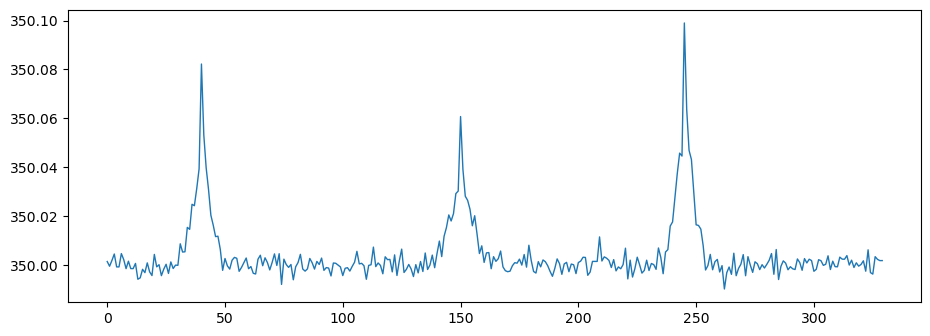

In [19]:
## RUN SCRIPT

n_points = 330
noise_std = 0.003
seed = 42

example_peaks = [
    {'pos': 40,  'amp': 0.04, 'tau': 0.95, 'rise_width': 4,  'tail_scale': 1},
    {'pos': 150, 'amp': 0.03,  'tau': 0.81, 'rise_width': 5,  'tail_scale': 1},
    {'pos': 245, 'amp': 0.05, 'tau': 0.92,  'rise_width': 3.7,  'tail_scale': 1},
]

# synthesize
t, y, peaks_df = synthesize_peaks(n_points=n_points, peaks=example_peaks,
                                      baseline=350, noise_std=noise_std, seed=seed)


# Save CSV
out_df = pd.DataFrame({'t': t, 'y': y})
folder = '/Users/mariaclaudia/Downloads'
csv_path = 'synthetic_peaks.csv'
out_df.to_csv(os.path.join(folder, csv_path), index=False)

# Plot
plt.figure(figsize=(11, 3.8))
plt.plot(t, y, linewidth=1, label='signal')